<a href="https://colab.research.google.com/github/jerry-phillips/Capstone-Survey-Existing-Research/blob/main/%20KMeans_Model_UMass_Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Section 1: Data Loading & Exploration

In [24]:
# imports
from google.colab import files
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# pick the file from computer
# link to file https://www.kaggle.com/datasets/jahnavipaliwal/video-game-reviews-and-ratings
uploaded = files.upload()

Saving video_game_reviews.csv to video_game_reviews (3).csv


In [3]:
# create dataframe
df = pd.read_csv('video_game_reviews.csv')
df.head()

,Game Title,User Rating,Age Group Targeted,Price,Platform,Requires Special Device,Developer,Publisher,Release Year,Genre,Multiplayer,Game Length (Hours),Graphics Quality,Soundtrack Quality,Story Quality,User Review Text,Game Mode,Min Number of Players
0,Grand Theft Auto V,36.4,All Ages,41.41,PC,No,Game Freak,Innersloth,2015,Adventure,No,55.3,Medium,Average,Poor,"Solid game, but too many bugs.",Offline,1
1,The Sims 4,38.3,Adults,57.56,PC,No,Nintendo,Electronic Arts,2015,Shooter,Yes,34.6,Low,Poor,Poor,"Solid game, but too many bugs.",Offline,3
2,Minecraft,26.8,Teens,44.93,PC,Yes,Bungie,Capcom,2012,Adventure,Yes,13.9,Low,Good,Average,"Great game, but the graphics could be better.",Offline,5
3,Bioshock Infinite,38.4,All Ages,48.29,Mobile,Yes,Game Freak,Nintendo,2015,Sports,No,41.9,Medium,Good,Excellent,"Solid game, but the graphics could be better.",Online,4
4,Half-Life: Alyx,30.1,Adults,55.49,PlayStation,Yes,Game Freak,Epic Games,2022,RPG,Yes,13.2,High,Poor,Good,"Great game, but too many bugs.",Offline,1


In [4]:
# See the shape and first few rows
print(df.shape)

(47774, 18)


In [5]:
# Check column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47774 entries, 0 to 47773
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Game Title               47774 non-null  object 
 1   User Rating              47774 non-null  float64
 2   Age Group Targeted       47774 non-null  object 
 3   Price                    47774 non-null  float64
 4   Platform                 47774 non-null  object 
 5   Requires Special Device  47774 non-null  object 
 6   Developer                47774 non-null  object 
 7   Publisher                47774 non-null  object 
 8   Release Year             47774 non-null  int64  
 9   Genre                    47774 non-null  object 
 10  Multiplayer              47774 non-null  object 
 11  Game Length (Hours)      47774 non-null  float64
 12  Graphics Quality         47774 non-null  object 
 13  Soundtrack Quality       47774 non-null  object 
 14  Story Quality         

In [6]:
# Check unique values for key categorical columns
for col in ['Genre', 'Platform', 'Age Group Targeted', 'Graphics Quality',
            'Soundtrack Quality', 'Story Quality', 'Multiplayer', 'Game Mode']:
    print(f"{col}: {df[col].nunique()} unique values -> {df[col].unique()}")
    print()

Genre: 10 unique values -> ['Adventure' 'Shooter' 'Sports' 'RPG' 'Simulation' 'Strategy' 'Fighting'
 'Action' 'Party' 'Puzzle']

Platform: 5 unique values -> ['PC' 'Mobile' 'PlayStation' 'Xbox' 'Nintendo Switch']

Age Group Targeted: 4 unique values -> ['All Ages' 'Adults' 'Teens' 'Kids']

Graphics Quality: 4 unique values -> ['Medium' 'Low' 'High' 'Ultra']

Soundtrack Quality: 4 unique values -> ['Average' 'Poor' 'Good' 'Excellent']

Story Quality: 4 unique values -> ['Poor' 'Average' 'Excellent' 'Good']

Multiplayer: 2 unique values -> ['No' 'Yes']

Game Mode: 2 unique values -> ['Offline' 'Online']



## Section 2: Data Preprocessing & Feature Engineering


In [7]:
# Make a copy to work with
df_model = df.copy()

# --- Ordinal Encoding ---
graphics_order = {'Low': 0, 'Medium': 1, 'High': 2, 'Ultra': 3}
soundtrack_order = {'Poor': 0, 'Average': 1, 'Good': 2, 'Excellent': 3}
story_order = {'Poor': 0, 'Average': 1, 'Good': 2, 'Excellent': 3}
age_order = {'Kids': 0, 'Teens': 1, 'All Ages': 2, 'Adults': 3}

df_model['Graphics Quality'] = df_model['Graphics Quality'].map(graphics_order)
df_model['Soundtrack Quality'] = df_model['Soundtrack Quality'].map(soundtrack_order)
df_model['Story Quality'] = df_model['Story Quality'].map(story_order)
df_model['Age Group Targeted'] = df_model['Age Group Targeted'].map(age_order)

# --- Binary Encoding ---
df_model['Multiplayer'] = df_model['Multiplayer'].map({'No': 0, 'Yes': 1})
df_model['Game Mode'] = df_model['Game Mode'].map({'Offline': 0, 'Online': 1})

# --- One-Hot Encoding ---
df_model = pd.get_dummies(df_model, columns=['Genre', 'Platform'], drop_first=False)

# --- Select features (drop non-feature columns) ---
drop_cols = ['Game Title', 'Developer', 'Publisher', 'User Review Text', 'Requires Special Device']
df_features = df_model.drop(columns=drop_cols)

# --- Scale everything ---
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_features), columns=df_features.columns)

print(f"Final feature set shape: {df_scaled.shape}")
df_scaled.head()

Final feature set shape: (47774, 26)


,User Rating,Age Group Targeted,Price,Release Year,Multiplayer,Game Length (Hours),Graphics Quality,Soundtrack Quality,Story Quality,Game Mode,...,Genre_RPG,Genre_Shooter,Genre_Simulation,Genre_Sports,Genre_Strategy,Platform_Mobile,Platform_Nintendo Switch,Platform_PC,Platform_PlayStation,Platform_Xbox
0,0.884851,0.455667,0.126615,-0.367734,-0.991537,1.437616,-0.449934,-0.454514,-1.336116,-0.997074,...,-0.337027,-0.336873,-0.333589,-0.331687,-0.336796,-0.501118,-0.501347,1.994236,-0.502556,-0.493522
1,1.136505,1.351698,1.528497,-0.367734,1.008535,0.133460,-1.348372,-1.349712,-1.336116,-0.997074,...,-0.337027,2.968480,-0.333589,-0.331687,-0.336796,-0.501118,-0.501347,1.994236,-0.502556,-0.493522
2,-0.386663,-0.440363,0.432164,-1.112662,1.008535,-1.170695,-1.348372,0.440685,-0.443791,-0.997074,...,-0.337027,-0.336873,-0.333589,-0.331687,-0.336796,-0.501118,-0.501347,1.994236,-0.502556,-0.493522
3,1.149750,0.455667,0.723825,-0.367734,-0.991537,0.593380,-0.449934,0.440685,1.340860,1.002935,...,-0.337027,-0.336873,-0.333589,3.014887,-0.336796,1.995537,-0.501347,-0.501445,-0.502556,-0.493522
4,0.050420,1.351698,1.348813,1.370431,1.008535,-1.214797,0.448505,-1.349712,0.448535,-0.997074,...,2.967123,-0.336873,-0.333589,-0.331687,-0.336796,-0.501118,-0.501347,-0.501445,1.989827,-0.493522


k=2: Inertia=1177865.31, Silhouette=0.0511
k=3: Inertia=1130812.53, Silhouette=0.0580
k=4: Inertia=1062961.46, Silhouette=0.0983
k=5: Inertia=1027571.73, Silhouette=0.1072
k=6: Inertia=976617.89, Silhouette=0.1401
k=7: Inertia=923560.25, Silhouette=0.1625
k=8: Inertia=870338.87, Silhouette=0.1851
k=9: Inertia=817217.45, Silhouette=0.2083
k=10: Inertia=764237.73, Silhouette=0.2335
k=11: Inertia=757590.11, Silhouette=0.2037
k=12: Inertia=751204.99, Silhouette=0.1904
k=13: Inertia=744775.03, Silhouette=0.1728
k=14: Inertia=738352.36, Silhouette=0.1548
k=15: Inertia=731604.72, Silhouette=0.1504


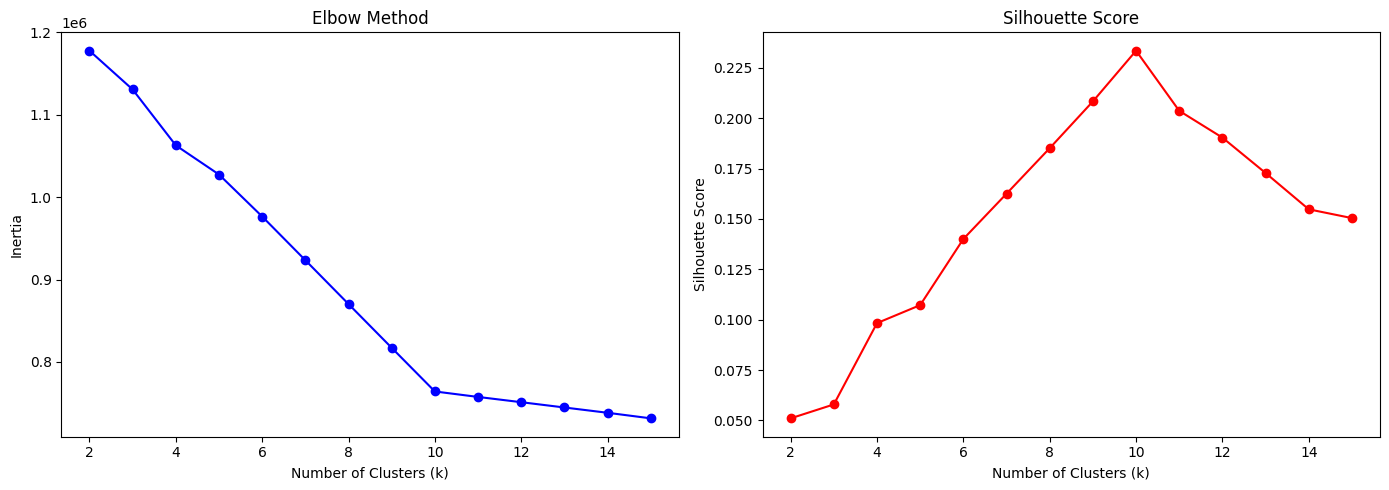

In [8]:
inertias = []
silhouette_scores = []
k_range = range(2, 16)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_, sample_size=5000, random_state=42))
    print(f"k={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={silhouette_scores[-1]:.4f}")

# Plot both
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertias, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')

ax2.plot(k_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')

plt.tight_layout()
plt.show()

## Section 3: Initial K-Means Exploration

In [9]:
# Train final K-Means model with k=10
kmeans_final = KMeans(n_clusters=10, random_state=42, n_init=10)
df_model['Cluster'] = kmeans_final.fit_predict(df_scaled)

# See how many games landed in each cluster
print("Games per cluster:")
print(df_model['Cluster'].value_counts().sort_index())
print()

# Inspect cluster profiles using original-scale features
profile_cols = ['User Rating', 'Price', 'Game Length (Hours)', 'Graphics Quality',
                'Soundtrack Quality', 'Story Quality', 'Release Year']
print("Cluster averages:")
df_model.groupby('Cluster')[profile_cols].mean().round(2)

Games per cluster:
Cluster
0    4867
1    4735
2    4869
3    4784
4    4822
5    4873
6    4750
7    4639
8    4687
9    4748
Name: count, dtype: int64

Cluster averages:


,User Rating,Price,Game Length (Hours),Graphics Quality,Soundtrack Quality,Story Quality,Release Year
Cluster,,,,,,,
0,29.72,39.95,32.51,1.50,1.53,1.52,2016.40
1,29.70,39.77,32.69,1.50,1.49,1.49,2016.52
2,29.63,40.04,32.06,1.49,1.50,1.49,2016.42
3,29.65,40.11,32.03,1.54,1.50,1.50,2016.45
4,29.76,39.97,32.58,1.50,1.51,1.50,2016.51
5,29.77,39.83,32.72,1.48,1.51,1.50,2016.31
6,29.70,39.76,32.74,1.50,1.53,1.52,2016.56
7,29.69,39.99,32.32,1.50,1.51,1.51,2016.54
8,29.79,39.77,33.02,1.49,1.48,1.48,2016.58


In [10]:
# Check genre and platform distribution per cluster
genre_cols = [col for col in df_model.columns if col.startswith('Genre_')]
platform_cols = [col for col in df_model.columns if col.startswith('Platform_')]

print("=== Dominant Genre per Cluster ===")
genre_profile = df_model.groupby('Cluster')[genre_cols].mean().round(3)
for cluster in range(10):
    top_genre = genre_profile.loc[cluster].idxmax().replace('Genre_', '')
    top_val = genre_profile.loc[cluster].max()
    print(f"Cluster {cluster}: {top_genre} ({top_val:.1%})")

print()
print("=== Dominant Platform per Cluster ===")
platform_profile = df_model.groupby('Cluster')[platform_cols].mean().round(3)
for cluster in range(10):
    top_platform = platform_profile.loc[cluster].idxmax().replace('Platform_', '')
    top_val = platform_profile.loc[cluster].max()
    print(f"Cluster {cluster}: {top_platform} ({top_val:.1%})")

=== Dominant Genre per Cluster ===
Cluster 0: Strategy (100.0%)
Cluster 1: Sports (100.0%)
Cluster 2: Shooter (100.0%)
Cluster 3: Simulation (100.0%)
Cluster 4: Puzzle (100.0%)
Cluster 5: RPG (100.0%)
Cluster 6: Adventure (100.0%)
Cluster 7: Action (100.0%)
Cluster 8: Fighting (100.0%)
Cluster 9: Party (100.0%)

=== Dominant Platform per Cluster ===
Cluster 0: PC (20.6%)
Cluster 1: Mobile (20.4%)
Cluster 2: Nintendo Switch (20.5%)
Cluster 3: Nintendo Switch (20.6%)
Cluster 4: Mobile (20.4%)
Cluster 5: PC (20.3%)
Cluster 6: Mobile (20.6%)
Cluster 7: Mobile (20.3%)
Cluster 8: PlayStation (20.6%)
Cluster 9: PlayStation (22.0%)


In [11]:
# Remove genre columns and re-scale
genre_cols = [col for col in df_features.columns if col.startswith('Genre_')]
df_features_no_genre = df_features.drop(columns=genre_cols)

scaler2 = StandardScaler()
df_scaled_no_genre = pd.DataFrame(scaler2.fit_transform(df_features_no_genre),
                                   columns=df_features_no_genre.columns)

# Re-run silhouette test for a few k values
for k in [5, 8, 10, 12]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_scaled_no_genre)
    score = silhouette_score(df_scaled_no_genre, labels, sample_size=5000, random_state=42)
    print(f"k={k}: Silhouette={score:.4f}")

k=5: Silhouette=0.2078
k=8: Silhouette=0.1374
k=10: Silhouette=0.1146
k=12: Silhouette=0.1048


In [12]:
# Train with k=5 on non-genre features
kmeans_no_genre = KMeans(n_clusters=5, random_state=42, n_init=10)
df_model['Cluster_v2'] = kmeans_no_genre.fit_predict(df_scaled_no_genre)

# Check cluster sizes
print("Games per cluster:")
print(df_model['Cluster_v2'].value_counts().sort_index())
print()

# Check numeric profiles
profile_cols = ['User Rating', 'Price', 'Game Length (Hours)', 'Graphics Quality',
                'Soundtrack Quality', 'Story Quality', 'Release Year', 'Min Number of Players']
print("Cluster averages:")
print(df_model.groupby('Cluster_v2')[profile_cols].mean().round(2))
print()

# Check platform distribution
print("=== Platform Distribution per Cluster ===")
platform_cols = [col for col in df_model.columns if col.startswith('Platform_')]
print(df_model.groupby('Cluster_v2')[platform_cols].mean().round(3))
print()

# Check categorical features
print("=== Other Features per Cluster ===")
cat_cols = ['Age Group Targeted', 'Multiplayer', 'Game Mode']
print(df_model.groupby('Cluster_v2')[cat_cols].mean().round(2))

Games per cluster:
Cluster_v2
0    9357
1    9589
2    9633
3    9596
4    9599
Name: count, dtype: int64

Cluster averages:
            User Rating  Price  Game Length (Hours)  Graphics Quality  \
Cluster_v2                                                              
0                 29.65  39.86                32.43              1.51   
1                 29.86  40.03                32.82              1.50   
2                 29.76  40.03                32.52              1.50   
3                 29.64  39.83                32.40              1.50   
4                 29.69  40.01                32.24              1.49   

            Soundtrack Quality  Story Quality  Release Year  \
Cluster_v2                                                    
0                         1.51           1.50       2016.50   
1                         1.51           1.50       2016.48   
2                         1.50           1.49       2016.49   
3                         1.51           1.50   

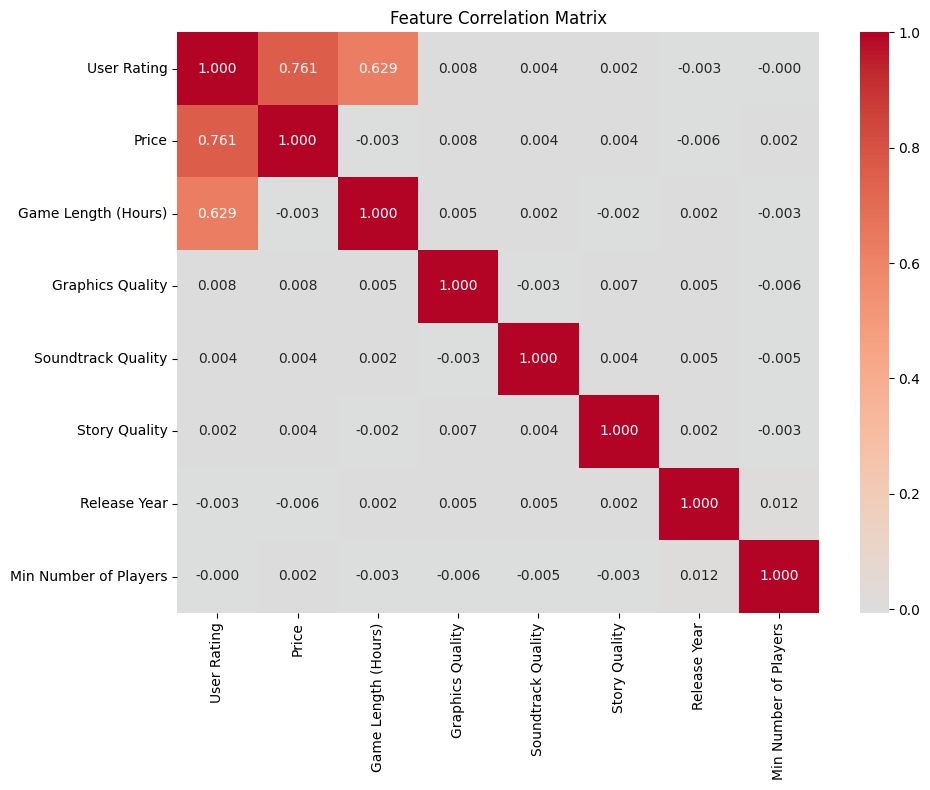

Standard deviations:
User Rating               7.55
Price                    11.52
Game Length (Hours)      15.87
Graphics Quality          1.11
Soundtrack Quality        1.12
Story Quality             1.12
Release Year              4.03
Min Number of Players     2.77
dtype: float64

Value ranges:
     User Rating  Price  Game Length (Hours)  Graphics Quality  \
min         10.1  19.99                  5.0               0.0   
max         49.5  59.99                 60.0               3.0   

     Soundtrack Quality  Story Quality  Release Year  Min Number of Players  
min                 0.0            0.0        2010.0                    1.0  
max                 3.0            3.0        2023.0                   10.0  


In [13]:
# Check if numeric features have any correlation with each other
numeric_cols = ['User Rating', 'Price', 'Game Length (Hours)', 'Graphics Quality',
                'Soundtrack Quality', 'Story Quality', 'Release Year', 'Min Number of Players']

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df_model[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.3f', ax=ax)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Also check the distributions
print("Standard deviations:")
print(df_model[numeric_cols].std().round(2))
print()
print("Value ranges:")
print(df_model[numeric_cols].describe().loc[['min', 'max']])

In [14]:
"""
### Key Findings from K-Means Exploration
- K-Means with k=10 clustered entirely by genre (100% alignment)
- Removing genre features caused clustering entirely by platform
- Correlation matrix shows near-zero correlations between all numeric features
- This indicates the dataset features are independently and uniformly distributed,
  making K-Means ineffective for finding meaningful sub-groups beyond categorical labels
"""


'\n### Key Findings from K-Means Exploration\n- K-Means with k=10 clustered entirely by genre (100% alignment)\n- Removing genre features caused clustering entirely by platform\n- Correlation matrix shows near-zero correlations between all numeric features\n- This indicates the dataset features are independently and uniformly distributed,\n  making K-Means ineffective for finding meaningful sub-groups beyond categorical labels\n'

## Section 4: Model Experimentation & Comparison

### 4.1 K-Means Clustering - Multi-Metric Evaluation


k=2: Silhouette=0.0511, Calinski-Harabasz=2606.23, Davies-Bouldin=4.2761
k=3: Silhouette=0.0580, Calinski-Harabasz=2351.18, Davies-Bouldin=3.8758
k=4: Silhouette=0.0983, Calinski-Harabasz=2683.88, Davies-Bouldin=3.0949
k=5: Silhouette=0.1072, Calinski-Harabasz=2493.49, Davies-Bouldin=2.9381
k=6: Silhouette=0.1401, Calinski-Harabasz=2597.27, Davies-Bouldin=2.7087
k=7: Silhouette=0.1625, Calinski-Harabasz=2746.05, Davies-Bouldin=2.5224
k=8: Silhouette=0.1851, Calinski-Harabasz=2914.91, Davies-Bouldin=2.2922
k=9: Silhouette=0.2083, Calinski-Harabasz=3104.39, Davies-Bouldin=2.1105
k=10: Silhouette=0.2335, Calinski-Harabasz=3318.60, Davies-Bouldin=1.6983
k=11: Silhouette=0.2037, Calinski-Harabasz=3054.79, Davies-Bouldin=1.9819
k=12: Silhouette=0.1904, Calinski-Harabasz=2837.54, Davies-Bouldin=2.2239
k=13: Silhouette=0.1728, Calinski-Harabasz=2657.84, Davies-Bouldin=2.4315
k=14: Silhouette=0.1548, Calinski-Harabasz=2506.64, Davies-Bouldin=2.4916
k=15: Silhouette=0.1504, Calinski-Harabasz=238

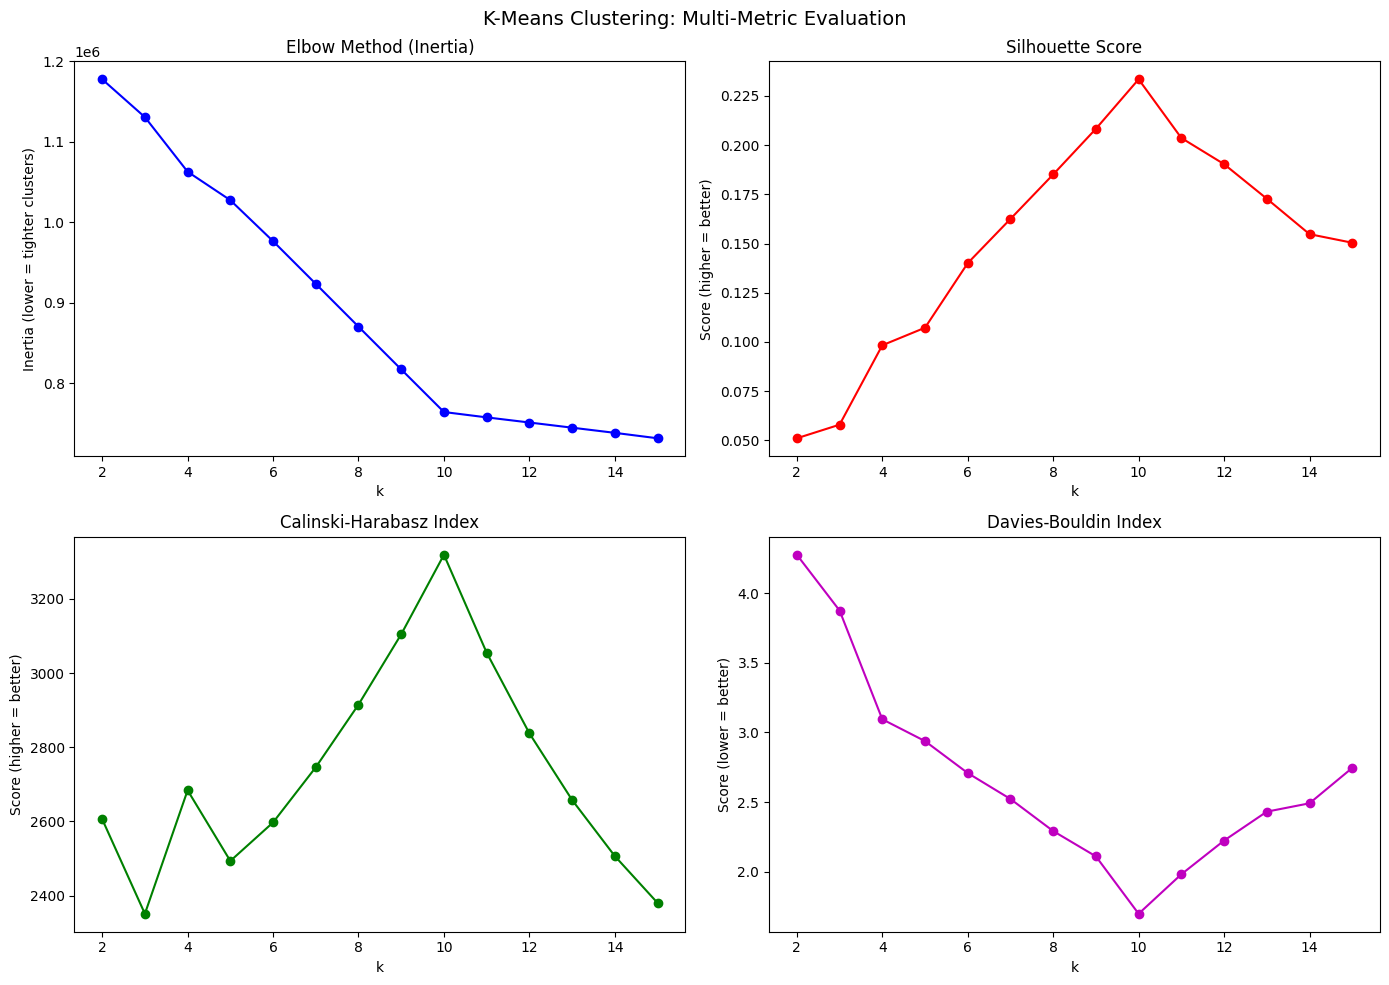


Best k by Silhouette Score: 10
Best k by Calinski-Harabasz Index: 10
Best k by Davies-Bouldin Index: 10


In [15]:
# Test K-Means across multiple k values with 3 evaluation metrics
k_range = range(2, 16)
kmeans_results = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)

    sil = silhouette_score(df_scaled, labels, sample_size=5000, random_state=42)
    cal = calinski_harabasz_score(df_scaled, labels)
    dav = davies_bouldin_score(df_scaled, labels)

    kmeans_results.append({
        'k': k,
        'inertia': kmeans.inertia_,
        'silhouette': sil,
        'calinski_harabasz': cal,
        'davies_bouldin': dav
    })
    print(f"k={k}: Silhouette={sil:.4f}, Calinski-Harabasz={cal:.2f}, Davies-Bouldin={dav:.4f}")

results_df = pd.DataFrame(kmeans_results)

# Plot all metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(results_df['k'], results_df['inertia'], 'bo-')
axes[0,0].set_title('Elbow Method (Inertia)')
axes[0,0].set_xlabel('k')
axes[0,0].set_ylabel('Inertia (lower = tighter clusters)')

axes[0,1].plot(results_df['k'], results_df['silhouette'], 'ro-')
axes[0,1].set_title('Silhouette Score')
axes[0,1].set_xlabel('k')
axes[0,1].set_ylabel('Score (higher = better)')

axes[1,0].plot(results_df['k'], results_df['calinski_harabasz'], 'go-')
axes[1,0].set_title('Calinski-Harabasz Index')
axes[1,0].set_xlabel('k')
axes[1,0].set_ylabel('Score (higher = better)')

axes[1,1].plot(results_df['k'], results_df['davies_bouldin'], 'mo-')
axes[1,1].set_title('Davies-Bouldin Index')
axes[1,1].set_xlabel('k')
axes[1,1].set_ylabel('Score (lower = better)')

plt.suptitle('K-Means Clustering: Multi-Metric Evaluation', fontsize=14)
plt.tight_layout()
plt.show()

# Summary
best_k_sil = results_df.loc[results_df['silhouette'].idxmax(), 'k']
best_k_cal = results_df.loc[results_df['calinski_harabasz'].idxmax(), 'k']
best_k_dav = results_df.loc[results_df['davies_bouldin'].idxmin(), 'k']
print(f"\nBest k by Silhouette Score: {best_k_sil}")
print(f"Best k by Calinski-Harabasz Index: {best_k_cal}")
print(f"Best k by Davies-Bouldin Index: {best_k_dav}")

In [16]:
"""
### 4.1 K-Means Summary
- All three metrics (Silhouette, Calinski-Harabasz, Davies-Bouldin) agree on k=10
- Silhouette: 0.2335 (highest = best cluster separation)
- Calinski-Harabasz: 3318.60 (highest = best defined clusters)
- Davies-Bouldin: 1.6983 (lowest = least cluster overlap)
- However, as shown in Section 3, these clusters map 1:1 to genre categories
- K-Means is effective at separating genres but does not discover deeper patterns
"""

'\n### 4.1 K-Means Summary\n- All three metrics (Silhouette, Calinski-Harabasz, Davies-Bouldin) agree on k=10\n- Silhouette: 0.2335 (highest = best cluster separation)\n- Calinski-Harabasz: 3318.60 (highest = best defined clusters)\n- Davies-Bouldin: 1.6983 (lowest = least cluster overlap)\n- However, as shown in Section 3, these clusters map 1:1 to genre categories\n- K-Means is effective at separating genres but does not discover deeper patterns\n'

### 4.2 Cosine Similarity - Content-Based Recommendations

In [19]:
# Compute cosine similarity matrix on the scaled features
def get_recommendations(game_title, df, df_scaled, n=5):
    """Given a game title, return the top n most similar games."""
    matches = df[df['Game Title'] == game_title].index
    if len(matches) == 0:
        print(f"Game '{game_title}' not found.")
        return None

    idx = matches[0]

    # Compute similarity only for this one game against all others
    game_vector = df_scaled.iloc[idx].values.reshape(1, -1)
    sim_scores = cosine_similarity(game_vector, df_scaled)[0]

    # Get top n+1 indices (excluding itself)
    top_indices = np.argsort(sim_scores)[::-1][1:n+1]
    top_scores = sim_scores[top_indices]

    results = df.loc[top_indices, ['Game Title', 'Genre', 'Platform', 'User Rating',
                                    'Price', 'Game Length (Hours)']].copy()
    results['Similarity Score'] = top_scores

    print(f"\nTop {n} recommendations for '{game_title}':")
    print(f"(Genre: {df.loc[idx, 'Genre']}, Platform: {df.loc[idx, 'Platform']}, "
          f"Rating: {df.loc[idx, 'User Rating']}, Price: ${df.loc[idx, 'Price']})")
    print("-" * 80)
    return results

# Test with a few different games
sample_games = df['Game Title'].unique()[:3]
for game in sample_games:
    result = get_recommendations(game, df, df_scaled, n=5)
    print(result.to_string(index=False))
    print()


Top 5 recommendations for 'Grand Theft Auto V':
(Genre: Adventure, Platform: PC, Rating: 36.4, Price: $41.41)
--------------------------------------------------------------------------------
           Game Title     Genre Platform  User Rating  Price  Game Length (Hours)  Similarity Score
   Kingdom Hearts III Adventure       PC         34.6  41.46                 51.9          0.935484
Red Dead Redemption 2 Adventure       PC         36.5  49.49                 44.9          0.918097
        Halo Infinite Adventure       PC         41.3  46.87                 57.7          0.914468
                Hades Adventure       PC         30.8  32.74                 52.2          0.910363
     Street Fighter V Adventure       PC         44.8  52.24                 57.9          0.896439


Top 5 recommendations for 'The Sims 4':
(Genre: Shooter, Platform: PC, Rating: 38.3, Price: $57.56)
--------------------------------------------------------------------------------
         Game Title   Gen

In [ ]:
# Tetris is not a shooter and some of these games do not fit well into the suggested genres, hence the simulated dataset

### 4.2.1 Cosine Similarity - Evaluation

In [20]:
def evaluate_recommendations(df, df_scaled, sample_size=100, n_recs=5):
    """Evaluate recommendation quality across a sample of games."""
    np.random.seed(42)
    sample_indices = np.random.choice(df.index, size=sample_size, replace=False)

    genre_match_rates = []
    platform_match_rates = []
    avg_similarities = []
    rating_diffs = []

    for idx in sample_indices:
        game_title = df.loc[idx, 'Game Title']
        game_vector = df_scaled.iloc[idx].values.reshape(1, -1)
        sim_scores = cosine_similarity(game_vector, df_scaled)[0]

        top_indices = np.argsort(sim_scores)[::-1][1:n_recs+1]
        top_scores = sim_scores[top_indices]

        # Genre match rate
        source_genre = df.loc[idx, 'Genre']
        rec_genres = df.loc[top_indices, 'Genre']
        genre_match_rates.append((rec_genres == source_genre).mean())

        # Platform match rate
        source_platform = df.loc[idx, 'Platform']
        rec_platforms = df.loc[top_indices, 'Platform']
        platform_match_rates.append((rec_platforms == source_platform).mean())

        # Average similarity score
        avg_similarities.append(top_scores.mean())

        # Average rating difference
        source_rating = df.loc[idx, 'User Rating']
        rec_ratings = df.loc[top_indices, 'User Rating']
        rating_diffs.append(np.abs(rec_ratings - source_rating).mean())

    print("=== Cosine Similarity Evaluation (averaged over 100 sample games) ===")
    print(f"Average Similarity Score:    {np.mean(avg_similarities):.4f}")
    print(f"Genre Match Rate:            {np.mean(genre_match_rates):.2%}")
    print(f"Platform Match Rate:         {np.mean(platform_match_rates):.2%}")
    print(f"Avg Rating Difference:       {np.mean(rating_diffs):.2f} points")

evaluate_recommendations(df, df_scaled, sample_size=100, n_recs=5)

=== Cosine Similarity Evaluation (averaged over 100 sample games) ===
Average Similarity Score:    0.9193
Genre Match Rate:            100.00%
Platform Match Rate:         100.00%
Avg Rating Difference:       3.43 points


### 4.3 Logistic Regression - Supervised Classification

Median User Rating: 29.7
Rating range: 10.1 - 49.5

Class distribution:
User Rating
0    23897
1    23877
Name: count, dtype: int64
Recommended: 49.98%

Train size: 38219, Test size: 9555

=== Logistic Regression Results ===
Accuracy:  0.9500
Precision: 0.9481
Recall:    0.9520
F1 Score:  0.9501

Classification Report:
                 precision    recall  f1-score   support

Not Recommended       0.95      0.95      0.95      4780
    Recommended       0.95      0.95      0.95      4775

       accuracy                           0.95      9555
      macro avg       0.95      0.95      0.95      9555
   weighted avg       0.95      0.95      0.95      9555



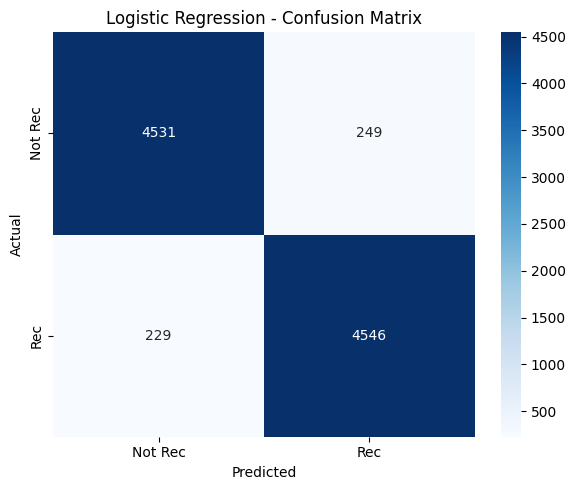

In [23]:
# Create binary target: 1 = "Recommended" (above median rating), 0 = "Not Recommended"
median_rating = df['User Rating'].median()
print(f"Median User Rating: {median_rating}")
print(f"Rating range: {df['User Rating'].min()} - {df['User Rating'].max()}")

y = (df['User Rating'] > median_rating).astype(int)
print(f"\nClass distribution:")
print(y.value_counts())
print(f"Recommended: {y.mean():.2%}")

# Use the scaled features but DROP User Rating since that's our target
X = df_scaled.drop(columns=['User Rating'])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# Train logistic regression with default parameters
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)

# Evaluation
print("\n=== Logistic Regression Results ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Recommended', 'Recommended']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Rec', 'Rec'], yticklabels=['Not Rec', 'Rec'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Logistic Regression - Confusion Matrix')
plt.tight_layout()
plt.show()

### 4.3.1 Logistic Regression - Cross-Validation & Hyperparameter Tuning

=== 5-Fold Cross-Validation (Default Parameters) ===
F1 Scores per fold: [0.9476 0.9477 0.9496 0.9513 0.9494]
Mean F1: 0.9491 (+/- 0.0014)
Fitting 5 folds for each of 10 candidates, totalling 50 fits

=== Hyperparameter Tuning Results ===
Best parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV F1 Score: 0.9494

=== Tuned Model - Test Set Results ===
Accuracy:  0.9498
F1 Score:  0.9498
                 precision    recall  f1-score   support

Not Recommended       0.95      0.95      0.95      4780
    Recommended       0.95      0.95      0.95      4775

       accuracy                           0.95      9555
      macro avg       0.95      0.95      0.95      9555
   weighted avg       0.95      0.95      0.95      9555


=== Top 10 Most Important Features ===
              Feature  Coefficient
                Price     8.415991
  Game Length (Hours)     6.978459
          Platform_PC     0.034221
          Multiplayer     0.033464
         Genre_Action     0.0296

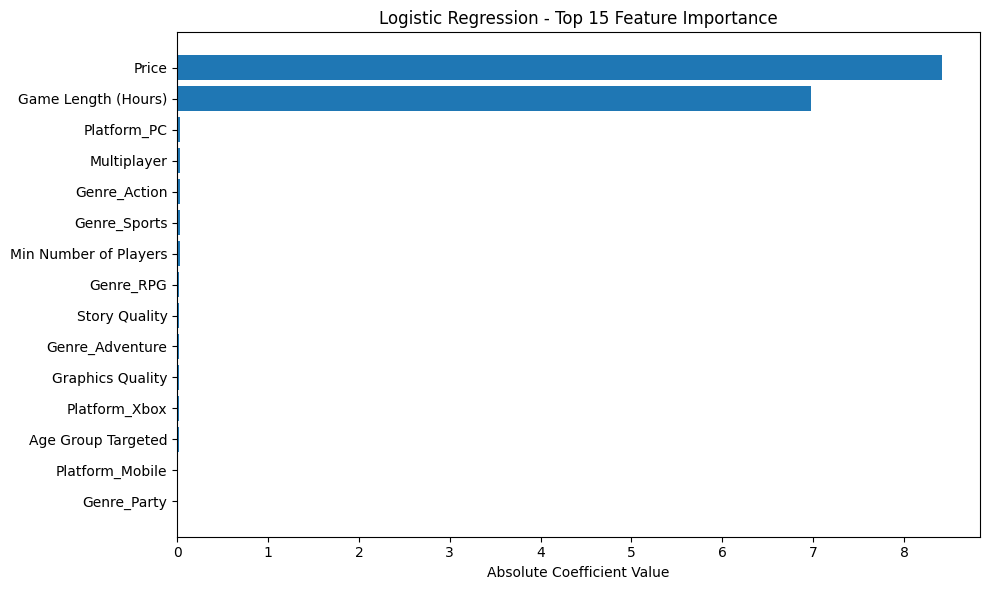

In [25]:

# 5-Fold Cross-Validation with default parameters
cv_scores = cross_val_score(log_reg, X, y, cv=5, scoring='f1')
print("=== 5-Fold Cross-Validation (Default Parameters) ===")
print(f"F1 Scores per fold: {cv_scores.round(4)}")
print(f"Mean F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Hyperparameter tuning
param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_search = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f"\n=== Hyperparameter Tuning Results ===")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")

# Evaluate best model on test set
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print(f"\n=== Tuned Model - Test Set Results ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_tuned):.4f}")
print(classification_report(y_test, y_pred_tuned, target_names=['Not Recommended', 'Recommended']))

# Feature importance - which features matter most?
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': np.abs(best_model.coef_[0])
}).sort_values('Coefficient', ascending=False)

print("\n=== Top 10 Most Important Features ===")
print(feature_importance.head(10).to_string(index=False))

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 6))
top_features = feature_importance.head(15)
ax.barh(top_features['Feature'], top_features['Coefficient'])
ax.set_xlabel('Absolute Coefficient Value')
ax.set_title('Logistic Regression - Top 15 Feature Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
"""
### 4.3 Logistic Regression Summary
- 95% accuracy and F1 score with balanced precision/recall
- Cross-validation confirms consistent performance (no overfitting)
- Hyperparameter tuning showed minimal improvement — default parameters already near-optimal
- Feature importance reveals Price and Game Length dominate predictions
  (coefficients of 8.42 and 6.98 vs <0.04 for all other features)
- This suggests User Rating in this dataset is primarily a function of Price and Game Length
"""

### 4.4 Model Comparison Summary

In [26]:
print("=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)

print("\n--- Model 1: K-Means Clustering (k=10) ---")
print(f"  Silhouette Score:        0.2335")
print(f"  Calinski-Harabasz Index: 3318.60")
print(f"  Davies-Bouldin Index:    1.6983")
print(f"  Finding: Clusters aligned 100% with genre categories")
print(f"  Limitation: No meaningful sub-groups beyond genre labels")

print("\n--- Model 2: Cosine Similarity ---")
print(f"  Avg Similarity Score:    0.9193")
print(f"  Genre Match Rate:        100.00%")
print(f"  Platform Match Rate:     100.00%")
print(f"  Avg Rating Difference:   3.43 points")
print(f"  Strength: Practical for game-to-game recommendations")

print("\n--- Model 3: Logistic Regression ---")
print(f"  Accuracy:                0.9500")
print(f"  F1 Score:                0.9501")
print(f"  Precision:               0.9481")
print(f"  Recall:                  0.9520")
print(f"  Cross-Val F1 (mean):     0.9498")
print(f"  Key Predictors:          Price, Game Length (Hours)")

print("\n--- Overall Findings ---")
print("""
1. The dataset exhibits uniformly distributed, independent features,
   which limits the effectiveness of unsupervised methods like K-Means.

2. Cosine Similarity is the most practical model for the recommendation
   use case, providing meaningful game-to-game similarity matching.

3. Logistic Regression achieved 95% accuracy for predicting whether a
   game would be recommended, driven almost entirely by Price and
   Game Length — suggesting these features have a hidden relationship
   with User Rating in this synthetic dataset.

4. For a production recommendation system, Cosine Similarity would be
   the recommended approach, potentially enhanced by allowing users to
   weight features based on their preferences (e.g., prioritize genre
   vs price vs game length).
""")

MODEL COMPARISON SUMMARY

--- Model 1: K-Means Clustering (k=10) ---
  Silhouette Score:        0.2335
  Calinski-Harabasz Index: 3318.60
  Davies-Bouldin Index:    1.6983
  Finding: Clusters aligned 100% with genre categories
  Limitation: No meaningful sub-groups beyond genre labels

--- Model 2: Cosine Similarity ---
  Avg Similarity Score:    0.9193
  Genre Match Rate:        100.00%
  Platform Match Rate:     100.00%
  Avg Rating Difference:   3.43 points
  Strength: Practical for game-to-game recommendations

--- Model 3: Logistic Regression ---
  Accuracy:                0.9500
  F1 Score:                0.9501
  Precision:               0.9481
  Recall:                  0.9520
  Cross-Val F1 (mean):     0.9498
  Key Predictors:          Price, Game Length (Hours)

--- Overall Findings ---

1. The dataset exhibits uniformly distributed, independent features,
   which limits the effectiveness of unsupervised methods like K-Means.

2. Cosine Similarity is the most practical model 